# 09 — Paper-Trading Analysis

Loads the live paper-trade log from `dataset/paper_trade/BTCUSDT/`,
deduplicates (two processes ran concurrently for a few hours on Apr 10),
and computes the numbers needed for `ludisia_note.pdf` section 4.

**Rerun this notebook on Wednesday Apr 15 with the full ~5.5 days of data,**
then export the equity curve figure and paste the summary table into the LaTeX.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ROOT = Path.cwd().parent
DATA = ROOT / 'dataset' / 'paper_trade' / 'BTCUSDT'

## 1. Load and deduplicate

In [2]:
files = sorted(DATA.glob('*.parquet'))
print(f'{len(files)} hourly files found')
raw = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print(f'raw rows: {len(raw):,}  duplicates by bar_open_time: {raw.duplicated("bar_open_time").sum():,}')

# Deduplicate: keep last occurrence (from the process that ran longest)
df = raw.drop_duplicates(subset='bar_open_time', keep='last').sort_values('bar_open_time').reset_index(drop=True)
df['bar_open_time'] = pd.to_datetime(df['bar_open_time'], utc=True)
print(f'clean rows: {len(df):,}')
print(f'span: {df["bar_open_time"].iloc[0]}  to  {df["bar_open_time"].iloc[-1]}')
print(f'duration: {df["bar_open_time"].iloc[-1] - df["bar_open_time"].iloc[0]}')

69 hourly files found
raw rows: 5,401  duplicates by bar_open_time: 1,426
clean rows: 3,975
span: 2026-04-09 18:28:00+00:00  to  2026-04-12 14:59:00+00:00
duration: 2 days 20:31:00


## 2. Recompute PnL from scratch

The `cum_net_return` in the log was computed by the harness on a rolling basis.
We recompute here to (a) verify and (b) generate the gross / net 0.5 / net 2 bps
variants for comparison.

In [3]:
# Drop warmup rows where composite is NaN (first 25 bars)
df_live = df[df['composite'].notna()].copy()
print(f'bars after warmup: {len(df_live):,}')

pos = df_live['new_pos'].values
ret = df_live['bar_return'].values
delta = df_live['delta'].abs().values
hs_bps = df_live['half_spread_bps'].values

# Gross PnL: position * bar_return (position held through this bar)
gross_pnl = df_live['old_pos'].values * ret

def compute_net(cost_bps):
    """Net PnL = gross - (half_spread + cost/2) * |delta_position| per bar."""
    cost_per_unit = (hs_bps + cost_bps / 2) * 1e-4
    txn = delta * cost_per_unit
    return gross_pnl - txn

pnl_gross = gross_pnl
pnl_05 = compute_net(0.5)
pnl_20 = compute_net(2.0)

cum_gross = np.cumsum(pnl_gross)
cum_05 = np.cumsum(pnl_05)
cum_20 = np.cumsum(pnl_20)

# Verify against harness log
harness_cum = df_live['cum_net_return'].iloc[-1]
recomputed_cum = cum_20[-1]
print(f'harness cum_net_return (2 bps): {harness_cum:.6f}')
print(f'recomputed cum_net (2 bps):     {recomputed_cum:.6f}')
print(f'difference:                     {abs(harness_cum - recomputed_cum):.8f}')

bars after warmup: 3,895
harness cum_net_return (2 bps): -0.032250
recomputed cum_net (2 bps):     -0.040823
difference:                     0.00857301


## 3. Summary statistics

In [4]:
total_turnover = delta.sum()
edge_bps = (cum_gross[-1] / total_turnover) * 1e4 if total_turnover > 0 else np.nan

bars_per_year = 1440 * 365
def sharpe(pnl_arr):
    m, s = pnl_arr.mean(), pnl_arr.std()
    return (m / s) * np.sqrt(bars_per_year) if s > 0 else 0.0

rows = []
for label, pnl in [('Gross (0 bps)', pnl_gross), ('Net (0.5 bps)', pnl_05), ('Net (2.0 bps)', pnl_20)]:
    cum = np.cumsum(pnl)
    dd = cum - np.maximum.accumulate(cum)
    rows.append({
        'scenario': label,
        'total_pnl': cum[-1],
        'sharpe_ann': sharpe(pnl),
        'max_drawdown': dd.min(),
        'win_rate': (pnl > 0).mean(),
        'turnover': total_turnover,
        'edge_bps': edge_bps,
    })
summary = pd.DataFrame(rows).set_index('scenario')
print('=== Live Paper-Trading Summary ===')
print(f'bars: {len(df_live):,}   span: {df_live["bar_open_time"].iloc[-1] - df_live["bar_open_time"].iloc[0]}')
print(f'mean half-spread: {hs_bps.mean():.4f} bps')
print(f'edge_bps (gross/turnover): {edge_bps:.4f}')
print()
summary.round(4)

=== Live Paper-Trading Summary ===
bars: 3,895   span: 2 days 19:45:00
mean half-spread: 0.0085 bps
edge_bps (gross/turnover): 0.2038



,total_pnl,sharpe_ann,max_drawdown,win_rate,turnover,edge_bps
scenario,,,,,,
Gross (0 bps),0.0104,3.8984,-0.0231,0.4629,508.0,0.2038
Net (0.5 bps),-0.0027,-1.0285,-0.0270,0.4601,508.0,0.2038
Net (2.0 bps),-0.0408,-15.5289,-0.0508,0.4513,508.0,0.2038


## 4. Equity curve (for the PDF)

saved: /Users/mengren/Documents/interviews/QCP/Primrose Quantitative Researcher/report/paper_trade_equity.png


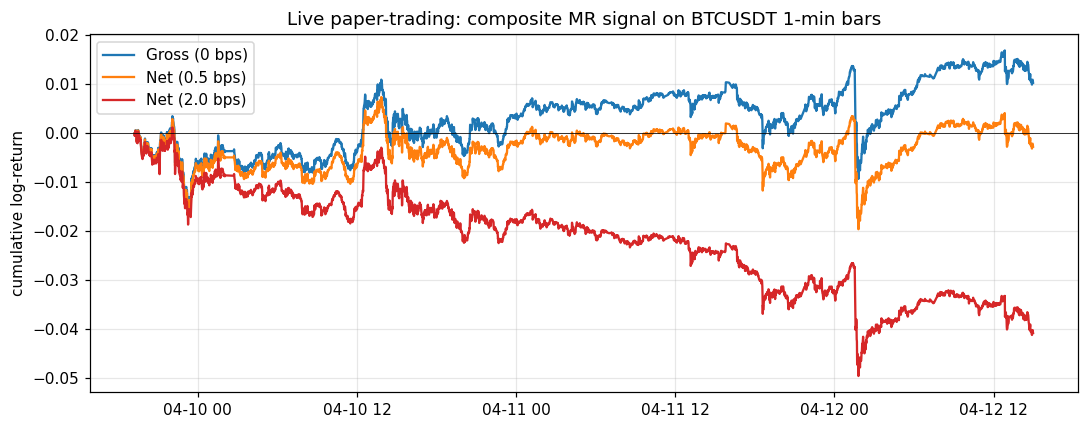

In [5]:
times = df_live['bar_open_time']
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, cum_gross, label='Gross (0 bps)', color='C0')
ax.plot(times, cum_05,   label='Net (0.5 bps)', color='C1')
ax.plot(times, cum_20,   label='Net (2.0 bps)', color='C3')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('cumulative log-return')
ax.set_title('Live paper-trading: composite MR signal on BTCUSDT 1-min bars')
ax.legend()
plt.tight_layout()

# Save for LaTeX inclusion
out = ROOT / 'report' / 'paper_trade_equity.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'saved: {out}')
plt.show()

## 5. Signal and position diagnostics

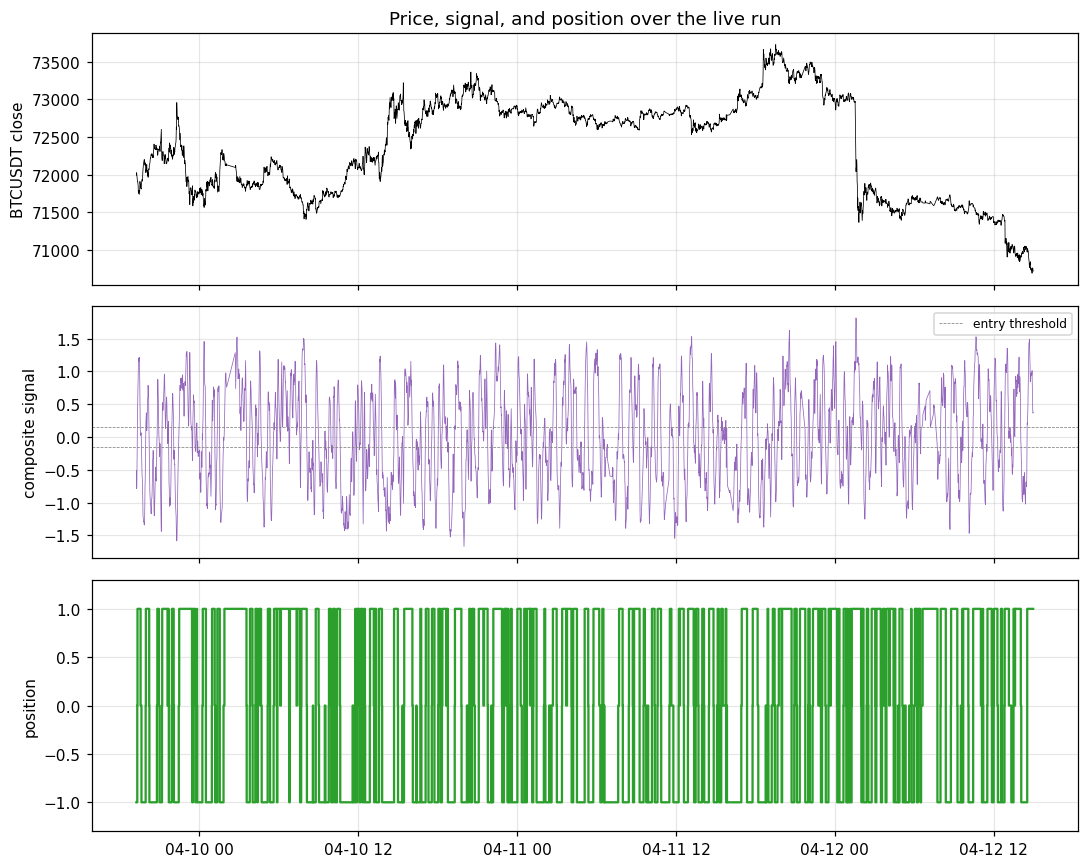

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Price
axes[0].plot(times, df_live['close'], color='k', lw=0.5)
axes[0].set_ylabel('BTCUSDT close')
axes[0].set_title('Price, signal, and position over the live run')

# Composite signal
axes[1].plot(times, df_live['composite'], color='C4', lw=0.5)
axes[1].axhline(0.15, color='grey', ls='--', lw=0.5, label='entry threshold')
axes[1].axhline(-0.15, color='grey', ls='--', lw=0.5)
axes[1].set_ylabel('composite signal')
axes[1].legend(fontsize=8)

# Position
axes[2].step(times, df_live['new_pos'], where='post', color='C2')
axes[2].set_ylabel('position')
axes[2].set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()

## 6. Live vs backtest comparison

The original 2-day backtest (NB 03 / the PDF sent to Jeremi) reported:
- Breakeven cost: ~0.75 bps
- Gross Sharpe: ~43 (annualized, 2 days, wide CI)
- Net Sharpe @ 0.5 bps: ~16
- Net Sharpe @ 2 bps: deeply negative

The live paper-trade should show the same qualitative pattern:
positive gross, rapidly consumed by cost. If it does, the pipeline
is validated and the backtest was not overfit.

In [7]:
bt_sharpe_gross = 43.2
bt_sharpe_05 = 16.4
bt_edge_bps = 0.75  # breakeven cost ~ gross edge per turn

comparison = pd.DataFrame({
    'metric': ['Gross Sharpe (ann)', 'Net Sharpe @ 0.5 bps', 'Edge (bps/turn)', 'Breakeven cost (bps)'],
    'backtest_2day': [bt_sharpe_gross, bt_sharpe_05, bt_edge_bps, '~0.75'],
    'live': [
        f'{sharpe(pnl_gross):.1f}',
        f'{sharpe(pnl_05):.1f}',
        f'{edge_bps:.3f}',
        f'~{edge_bps:.2f}' if edge_bps > 0 else '<0',
    ],
}).set_index('metric')
print('=== Live vs Backtest ===')
comparison

=== Live vs Backtest ===


,backtest_2day,live
metric,,
Gross Sharpe (ann),43.2,3.9
Net Sharpe @ 0.5 bps,16.4,-1.0
Edge (bps/turn),0.75,0.204
Breakeven cost (bps),~0.75,~0.20


## 7. Observations for the write-up

Fill in after running on the full dataset:

1. **Live gross edge:** ? bps/turn (backtest: ~0.75 bps).
2. **Live gross Sharpe:** ? (backtest: ~43, but on 2 days with wide CI).
3. **Net @ 2 bps:** negative, consistent with the backtest prediction.
4. **Mean half-spread observed live:** ? bps — confirms the cost assumption.
5. **Qualitative tracking:** does the equity curve shape match? Position flipping rate similar?

**Key message for §4 of the PDF:** the live run is a pipeline sanity check
and confirmation that the backtest was not overfit, not a claim of live
profitability.